In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [12]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


In [2]:
key_celltype = "broad_celltypes"

In [3]:
DATA_PREPARED=True
DATA_PREPARED_T=True



In [4]:
if not DATA_PREPARED:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_10ad_spatial.h5ad')
else:
   #adata=sc.read_h5ad('/nfs/team361/ls34/adata_mm_spatial_prepped.h5ad')
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_eczema_spatial_prepped.h5ad')

try:
    adata.obs["NICHE_NAMES"] = adata.obs["niche_name"]
except:
    adata
    
  

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 197487 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'key_celltype_new'
    uns: 'NICHE_NAMES_colors', 'de_leiden', 'inflow_biological_batch_ID_colors', 'inflow_cell_type_colors',

In [5]:
CATEGORY="spatial_niche"
 

In [7]:
gene_programme = ['CD3E',
 'CXCR4',
 'CYBA',
 'CD4',
 'CCR4',
 'ITGB2',
 'ADAM8',
 'TNFRSF1B',
 'PLEC',
 'JAK3',
 'IL2RG',
 'FSCN1',
 'CD5',
 'SELPLG',
 'ACAP1',
 'ITGAL',
 'IKZF1',
 'CD247',
 'CD83',
 'CCL22',
 'CCR7',
 'CCL17',
 'MYH9',
 'RUNX3',
 'CFLAR',
 'BATF',
 'ZAP70',
 'LAMP3',
 'ALOX15',
 'UCP2',
 'FOXP3',
 'SEPTIN9',
 'CCL19',
 'GRK2',
 'MIAT',
 'CD6',
 'TNFRSF18',
 'IKZF3',
 'TCF7',
 'PIM2',
 'IL21R',
 'CTLA4',
 'CD7',
 'MSN',
 'SLC2A3',
 'TRAF1',
 'RFTN1',
 'FURIN',
 'SH2D2A',
 'SERPINB9',
 'IL2RB',
 'IRF4',
 'IL2RA',
 'RASGRP1',
 'CD96',
 'CSF2RB',
 'CD27',
 'TAP1',
 'TUBB',
 'TMEM173',
 'ZYX',
 'CD1B',
 'CD8A',
 'GIMAP5',
 'CLEC10A',
 'CDKN1A',
 'CD44',
 'TIGIT',
 'IRF1',
 'CD1E',
 'CTSH',
 'CST7',
 'MMP9',
 'ARF6',
 'PKM',
 'KCNN4',
 'PPP1CA',
 'CSF2RA',
 'SPI1',
 'CD40LG',
 'CFP',
 'HNRNPH1',
 'MMP12',
 'ADAM12',
 'CIITA',
 'PFKFB3',
 'PGK1',
 'CD274',
 'FLII',
 'HSPA8',
 'TNFRSF9',
 'LMNB1',
 'NR4A3',
 'DUSP5',
 'WDFY4',
 'HCK',
 'CD1C',
 'CXCR3',
 'SND1',
 'CD99',
 'EBI3',
 'PRDM1',
 'TUBB2B',
 'CD1A',
 'XBP1',
 'CPVL',
 'MCM5',
 'CTBP1',
 'TENT5C',
 'ADAR',
 'SF3A1',
 'FCER1A',
 'CCAR2',
 'SORL1',
 'NAP1L4',
 'MICAL2',
 'TNF',
 'ITGAX',
 'HNRNPA1L2',
 'DDX6',
 'ICAM1',
 'DDX39B',
 'PARK7',
 'ZMIZ2',
 'HYOU1',
 'IRF8',
 'ALOX5',
 'TNFRSF8',
 'ITGAE',
 'HNRNPUL1',
 'LTA',
 'GZMA',
 'LAG3',
 'AP3D1',
 'SOAT1',
 'MAL',
 'KHDRBS1',
 'SLC7A5',
 'CD82',
 'OGDH',
 'LAIR2',
 'ACHE',
 'ILF3',
 'PIM1',
 'FCGBP',
 'KDM6B',
 'SMARCC1',
 'GLS',
 'RBMX',
 'CSF1R',
 'ALYREF',
 'KRTCAP2',
 'PLAUR',
 'CCR2',
 'PRPF8',
 'IDO1',
 'HNRNPM',
 'PDIA3',
 'GZMB',
 'RHOA',
 'TES',
 'LPIN1',
 'PRRC2A',
 'NONO',
 'FPR1',
 'AP1B1',
 'IL17RB',
 'CPSF6',
 'PRKAR1A',
 'MAP7D1',
 'PDIA4',
 'DNM2',
 'SOCS3',
 'TSPAN14',
 'KLF16',
 'PADI2',
 'HDC',
 'CD207',
 'HPGD',
 'HNRNPF',
 'APMAP',
 'CSF2',
 'GANAB',
 'CTSG',
 'DNASE1L3',
 'HNRNPD',
 'POLR2A',
 'SNRPB',
 'CTSC',
 'RPN1',
 'SDHA',
 'NR1H2',
 'NCOR2',
 'XRCC6',
 'ICAM2',
 'CCL18',
 'XRCC5',
 'GZMH',
 'CMA1',
 'IL13']

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


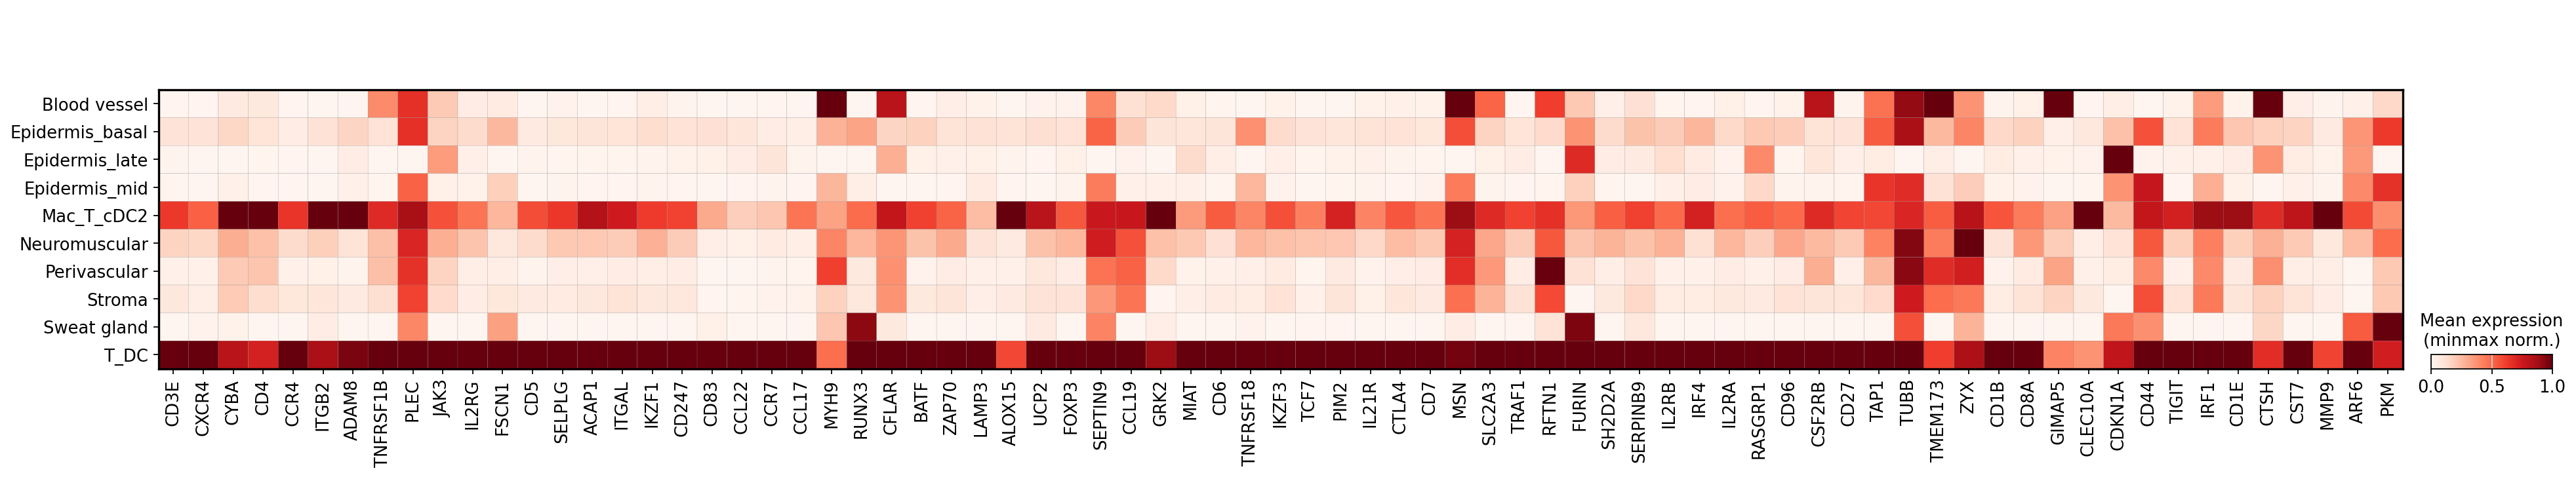

In [13]:
sc.pl.matrixplot(
    adata,
    gene_programme[:75],
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
    cmap="Reds",
    colorbar_title="Mean expression\n(minmax norm.)",
    save="Tzone_MGP.pdf"

)

